# Notebook 04 — Real Image Pixel-Domain Compressed Sensing

This notebook evaluates whether the sparse-recovery models studied on synthetic data transfer to real image-like data.

We use either MNIST or FashionMNIST directly in the pixel domain, controlled by the experiment configuration. Each image is flattened into a vector \(x \in \mathbb{R}^{784}\), and compressed measurements are generated by

$$
b = A x + \epsilon.
$$

Unlike the synthetic sparse setting, image data is not exactly sparse. It is only sparse/compressible in the pixel domain because many background pixels are near zero. This notebook therefore tests the robustness of unfolded sparse-recovery models beyond ideal synthetic sparse signals.

We compare:

- classical baselines: ISTA and FISTA,
- our best ISTA-derived scalar model: StepThresholdISTA,
- learned unfolded models: LISTA-L2 and ALISTA,
- HyperLISTA as a lightweight model-based reference.

In [8]:
import sys, os, json, time
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.image_loader import build_pixel_cs_dataloaders
from src.models.ista import ISTA
from src.models.fista import FISTA
from src.models.learned_ista import StepThresholdISTA
from src.models.lista import LISTA
from src.models.alista import ALISTA
from src.models.hyperlista import HyperLISTA

from src.training.trainer import train
from src.training.tuner import tune_hyperlista
from src.evaluation.metrics import psnr, ssim_batch, evaluate_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {device}")

Device: cuda


In [9]:
# ============================================================
# Experiment configuration
# ============================================================

DATASET_NAME = "mnist"          # "mnist" or "fashionmnist"
MEASUREMENT_RATIO = 0.5         # e.g. 0.25 or 0.5
SIGMA = 0.0
BATCH_SIZE = 256
N_VAL = 5000
K = 16
LAM = 0.01

RUN_ALISTA = True
RUN_HYPERLISTA = True

DATA_ROOT = "../data"

def make_tag(value):
    """Convert numeric values to compact path-safe tags."""
    if isinstance(value, float):
        return str(value).replace(".", "")
    return str(value)

ratio_tag = make_tag(MEASUREMENT_RATIO)
sigma_tag = make_tag(SIGMA)

EXPERIMENT_ID = (
    f"{DATASET_NAME}"
    f"_ratio{ratio_tag}"
    f"_sigma{sigma_tag}"
    f"_K{K}"
    f"_lamsweep"
    f"_seed{SEED}"
)

RESULTS_DIR = os.path.join("../results/notebook_04", EXPERIMENT_ID)
CKPT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TABLE_DIR = os.path.join(RESULTS_DIR, "tables")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

config = {
    "dataset_name": DATASET_NAME,
    "measurement_ratio": MEASUREMENT_RATIO,
    "sigma": SIGMA,
    "batch_size": BATCH_SIZE,
    "n_val": N_VAL,
    "K": K,
    "lambda": LAM,
    "seed": SEED,
    "run_alista": RUN_ALISTA,
    "run_hyperlista": RUN_HYPERLISTA,
}

with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print(f"Experiment ID: {EXPERIMENT_ID}")
print(f"Results directory: {RESULTS_DIR}")

Experiment ID: mnist_ratio05_sigma00_K16_lamsweep_seed42
Results directory: ../results/notebook_04\mnist_ratio05_sigma00_K16_lamsweep_seed42


## 1. Pixel-Domain Image Setup

The dataset, measurement ratio, noise level, number of unfolded layers, and regularization parameter are controlled by the experiment configuration above.

The dataset is split into train, validation, and test sets. Validation is used for early stopping and HyperLISTA tuning, while the test set is used only for final evaluation.

In [10]:
A, train_loader, val_loader, test_loader = build_pixel_cs_dataloaders(
    dataset_name=DATASET_NAME,
    measurement_ratio=MEASUREMENT_RATIO,
    sigma=SIGMA,
    batch_size=BATCH_SIZE,
    data_root=DATA_ROOT,
    device=device,
    seed=SEED,
    n_val=N_VAL,
)

torch.save(A.detach().cpu(), os.path.join(CKPT_DIR, "A.pt"))

d = A.shape[1]
m = A.shape[0]

print(f"Dataset: {DATASET_NAME}")
print(f"A: {tuple(A.shape)}")
print(f"m={m}, d={d}, measurement ratio={MEASUREMENT_RATIO}")
print(f"train samples: {len(train_loader.dataset)}")
print(f"val samples:   {len(val_loader.dataset)}")
print(f"test samples:  {len(test_loader.dataset)}")
print(f"K={K}, lambda={LAM}, sigma={SIGMA}")

Dataset: mnist
A: (392, 784)
m=392, d=784, measurement ratio=0.5
train samples: 55000
val samples:   5000
test samples:  10000
K=16, lambda=0.01, sigma=0.0


## Lambda Selection for Classical Baselines

Before training learned unfolded models, we perform a small validation sweep over \(\lambda\) for ISTA and FISTA.

This helps ensure that poor classical baseline performance is not simply caused by a bad regularization choice.

In [11]:
@torch.no_grad()
def final_nmse_db_on_loader(model, loader, device):
    model.eval()
    model.to(device)

    values = []

    for batch in loader:
        b, x_true = batch[0].to(device), batch[1].to(device)
        x_hat = model(b)

        num = ((x_hat - x_true) ** 2).sum(dim=-1)
        den = (x_true ** 2).sum(dim=-1).clamp(min=1e-12)
        nmse = (num / den).mean()
        values.append(10.0 * torch.log10(nmse.clamp(min=1e-30)).item())

    return float(np.mean(values))

In [12]:
LAMBDA_GRID = [0.001, 0.003, 0.01, 0.03, 0.1, 0.2, 0.3, 0.5, 1.0]

lambda_sweep_rows = []

print(f"{'lambda':>10} {'ISTA val NMSE':>16} {'FISTA val NMSE':>16}")
print("-" * 46)

for lam in LAMBDA_GRID:
    ista_tmp = ISTA(A, lam=lam, n_iter=K)
    fista_tmp = FISTA(A, lam=lam, n_iter=K)

    ista_val = final_nmse_db_on_loader(ista_tmp, val_loader, device)
    fista_val = final_nmse_db_on_loader(fista_tmp, val_loader, device)

    lambda_sweep_rows.append({
        "lambda": lam,
        "ista_val_nmse_db": ista_val,
        "fista_val_nmse_db": fista_val,
    })

    print(f"{lam:>10.4g} {ista_val:>16.3f} {fista_val:>16.3f}")

lambda_sweep_df = pd.DataFrame(lambda_sweep_rows)
lambda_sweep_path = os.path.join(TABLE_DIR, "lambda_sweep.csv")
lambda_sweep_df.to_csv(lambda_sweep_path, index=False)

best_row = lambda_sweep_df.loc[
    lambda_sweep_df["fista_val_nmse_db"].idxmin()
]

LAM = float(best_row["lambda"])

config["selected_lambda"] = LAM
config["lambda_selection"] = "best FISTA validation NMSE over LAMBDA_GRID"

with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

display(lambda_sweep_df)

print()
print(f"Selected lambda: {LAM}")
print(f"Saved lambda sweep to: {lambda_sweep_path}")

    lambda    ISTA val NMSE   FISTA val NMSE
----------------------------------------------
     0.001           -2.909           -3.053
     0.003           -2.947           -3.190
      0.01           -3.076           -3.624
      0.03           -3.382           -4.540
       0.1           -3.884           -5.630
       0.2           -3.772           -4.980
       0.3           -3.306           -3.941
       0.5           -2.273           -2.393
         1           -0.712           -0.712


,lambda,ista_val_nmse_db,fista_val_nmse_db
0,0.001,-2.908511,-3.053151
1,0.003,-2.947282,-3.190343
2,0.010,-3.076022,-3.624163
3,0.030,-3.382225,-4.539549
4,0.100,-3.884229,-5.630335
5,0.200,-3.771968,-4.980498
6,0.300,-3.306332,-3.941065
7,0.500,-2.273140,-2.393262
8,1.000,-0.712411,-0.711869



Selected lambda: 0.1
Saved lambda sweep to: ../results/notebook_04\mnist_ratio05_sigma00_K16_lamsweep_seed42\tables\lambda_sweep.csv


## 2. Visualizing Pixel-Domain Images

Before training unfolded models, we inspect the image data.

Each sample is a flattened \(28 \times 28\) image with values in \([0,1]\).  
Unlike the synthetic sparse signals, these images are not exactly sparse, but many background pixels are close to zero. This makes the pixel-domain sparse-recovery assumption only approximately valid.

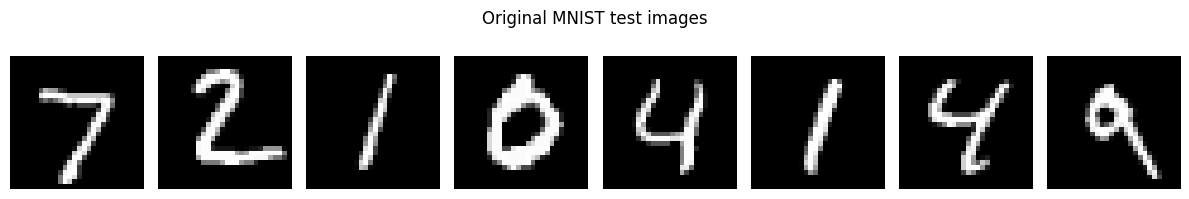

Saved figure to: ../results/notebook_04\mnist_ratio05_sigma00_K16_lamsweep_seed42\figures\original_mnist_samples.pdf


In [13]:
# Fixed visualization batch
b_vis, x_vis = next(iter(test_loader))
b_vis = b_vis.to(device)
x_vis = x_vis.to(device)

N_SHOW = 8

plt.figure(figsize=(12, 2))

for i in range(N_SHOW):
    plt.subplot(1, N_SHOW, i + 1)
    plt.imshow(x_vis[i].detach().cpu().reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle(f"Original {DATASET_NAME.upper()} test images")
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, f"original_{DATASET_NAME}_samples.pdf")
plt.savefig(fig_path)
plt.show()

print(f"Saved figure to: {fig_path}")

### Pixel-Domain Compressibility

We estimate how many pixels are close to zero. This does not prove exact sparsity, but it helps explain why pixel-domain sparse recovery can be meaningful for FashionMNIST.

In [14]:
@torch.no_grad()
def estimate_pixel_statistics(loader, max_batches=20, eps=1e-3):
    near_zero_fracs = []
    mean_l1 = []
    mean_l2 = []

    for i, batch in enumerate(loader):
        if i >= max_batches:
            break

        _, x = batch
        x = x.to(device)

        near_zero = (x.abs() < eps).float().mean(dim=1)
        near_zero_fracs.append(near_zero.mean().item())

        mean_l1.append(x.abs().mean().item())
        mean_l2.append(torch.sqrt((x ** 2).mean(dim=1)).mean().item())

    return {
        "near_zero_fraction": float(np.mean(near_zero_fracs)),
        "mean_abs_pixel": float(np.mean(mean_l1)),
        "mean_rms_pixel": float(np.mean(mean_l2)),
    }


pixel_stats = estimate_pixel_statistics(train_loader, max_batches=20, eps=1e-3)

print("Pixel-domain statistics:")
for k, v in pixel_stats.items():
    print(f"{k}: {v:.4f}")

Pixel-domain statistics:
near_zero_fraction: 0.8080
mean_abs_pixel: 0.1314
mean_rms_pixel: 0.3300


## 3. Evaluation Helpers

For image reconstruction we report:

- **NMSE (dB)** on the reconstructed pixel vector,
- **PSNR** after clamping reconstructions to \([0,1]\),
- **SSIM** after reshaping to \(28 \times 28\),
- runtime and number of learned/tuned parameters.

NMSE measures reconstruction error in vector space, while PSNR and SSIM are more image-oriented metrics.

In [15]:
results = {}
layer_curves = {}
histories = {}
reconstructions = {}


def safe_name(name):
    return name.lower().replace(" ", "_").replace("-", "_")


def nmse_db_batch(x_hat, x_true, eps=1e-12):
    num = ((x_hat - x_true) ** 2).sum(dim=-1)
    den = (x_true ** 2).sum(dim=-1).clamp(min=eps)
    nmse = (num / den).mean()
    return 10.0 * torch.log10(nmse.clamp(min=1e-30)).item()


@torch.no_grad()
def layerwise_nmse_db(model, loader, device):
    model.eval()
    model.to(device)

    sums = None
    n_batches = 0

    for batch in loader:
        b, x_true = batch[0].to(device), batch[1].to(device)
        iterates = model(b, return_all=True)

        if sums is None:
            sums = [0.0 for _ in iterates]

        for k, x_hat_k in enumerate(iterates):
            sums[k] += nmse_db_batch(x_hat_k, x_true)

        n_batches += 1

    return [v / n_batches for v in sums]


@torch.no_grad()
def image_quality_metrics(model, loader, device):
    model.eval()
    model.to(device)

    psnr_vals = []
    ssim_vals = []

    for batch in loader:
        b, x_true = batch[0].to(device), batch[1].to(device)

        x_hat = model(b)
        x_hat_img = x_hat.clamp(0.0, 1.0)

        psnr_vals.append(psnr(x_hat_img, x_true, max_val=1.0))
        ssim_vals.append(ssim_batch(x_hat_img, x_true, H=28, W=28, data_range=1.0))

    return {
        "psnr": float(np.mean(psnr_vals)),
        "ssim": float(np.mean(ssim_vals)),
    }


@torch.no_grad()
def store_visual_reconstructions(name, model):
    model.eval()
    model.to(device)

    x_hat = model(b_vis).clamp(0.0, 1.0)
    reconstructions[name] = x_hat[:N_SHOW].detach().cpu()


def evaluate_and_store(name, model, training_type, save_checkpoint=False):
    model.to(device)

    metrics = evaluate_model(
        model,
        test_loader,
        device=device,
        image_mode=False,
        measure_time=True,
    )
    image_metrics = image_quality_metrics(model, test_loader, device)
    metrics.update(image_metrics)

    results[name] = {
        "nmse_db": metrics["nmse_db"],
        "psnr": metrics["psnr"],
        "ssim": metrics["ssim"],
        "runtime_ms": metrics["runtime_ms"],
        "n_params": metrics["n_params"],
        "training": training_type,
    }

    layer_curves[name] = layerwise_nmse_db(model, test_loader, device)
    store_visual_reconstructions(name, model)

    if save_checkpoint:
        torch.save(
            model.state_dict(),
            os.path.join(CKPT_DIR, f"{safe_name(name)}.pt"),
        )

    print(
        f"{name:<22} "
        f"NMSE={metrics['nmse_db']:>8.3f} dB | "
        f"PSNR={metrics['psnr']:>6.2f} | "
        f"SSIM={metrics['ssim']:>6.3f} | "
        f"params={metrics['n_params']:>10} | "
        f"runtime={metrics['runtime_ms']:>8.3f} ms"
    )

## 4. Classical Baselines: ISTA and FISTA

We first evaluate ISTA and FISTA directly on pixel-domain FashionMNIST compressed measurements.

These baselines use the same sparse-recovery prior as before, but the signal is now an image rather than an exactly sparse synthetic vector.

In [16]:
ista = ISTA(A, lam=LAM, n_iter=K)
fista = FISTA(A, lam=LAM, n_iter=K)

print("Classical pixel-domain baselines:")
evaluate_and_store("ISTA", ista, training_type="none")
evaluate_and_store("FISTA", fista, training_type="none")

Classical pixel-domain baselines:
ISTA                   NMSE=  -3.844 dB | PSNR= 13.56 | SSIM= 0.429 | params=         0 | runtime=   7.768 ms
FISTA                  NMSE=  -5.522 dB | PSNR= 14.93 | SSIM= 0.588 | params=         0 | runtime=   9.123 ms


## 5. Our ISTA-Derived Scalar Model: StepThresholdISTA

We now evaluate our best scalar ISTA-derived model from Notebook 03.

StepThresholdISTA preserves the ISTA correction direction

$$
A^T(b-Ax^k)
$$

but learns a per-layer step size and threshold:

$$
x^{k+1}
=
S_{\theta_k}
\left(
x^k+\gamma_k A^T(b-Ax^k)
\right).
$$

This tests whether the scalar schedules that worked well on synthetic sparse data also transfer to pixel-domain FashionMNIST.

In [17]:
torch.manual_seed(SEED)

step_threshold_ista = StepThresholdISTA(A, n_layers=K, lam=LAM).to(device)

print("Training StepThresholdISTA")

t0 = time.time()

history = train(
    model=step_threshold_ista,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=1e-2,
    weight_decay=1e-5,
    device=device,
    patience=10,
    intermediate_weight=0.0,
    verbose=True,
)

train_sec = time.time() - t0

histories["StepThresholdISTA"] = history

evaluate_and_store(
    name="StepThresholdISTA",
    model=step_threshold_ista,
    training_type=f"final loss ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training StepThresholdISTA


Training: 100%|██████████| 50/50 [19:59<00:00, 23.99s/epoch, lr=1.00e-02, train_loss=0.0226, val_nmse=-8.12 dB]


StepThresholdISTA      NMSE=  -7.920 dB | PSNR= 17.24 | SSIM= 0.739 | params=        32 | runtime=   8.460 ms


## 6. LISTA-L2 on Pixel-Domain Images

We now train LISTA with intermediate supervision.

Unlike StepThresholdISTA, LISTA learns full matrices in each unfolded layer:

$$
x^{k+1}
=
S_{\theta_k}
\left(
W_y^k b + W_x^k x^k
\right).
$$

This gives the model much higher capacity and may allow it to learn image-specific reconstruction behavior that is not captured by scalar ISTA schedules alone.

We use L2-style intermediate supervision because it performed best among LISTA training strategies in Notebook 03.

In [18]:
torch.manual_seed(SEED)

lista_l2 = LISTA(A, n_layers=K, tied=False, lam=LAM).to(device)

print("Training LISTA-L2")

t0 = time.time()

history = train(
    model=lista_l2,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=5e-4,
    weight_decay=0.0,
    device=device,
    patience=15,
    intermediate_weight=0.1,
    verbose=True,
)

train_sec = time.time() - t0

histories["LISTA-L2"] = history

evaluate_and_store(
    name="LISTA-L2",
    model=lista_l2,
    training_type=f"L2 intermediate ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training LISTA-L2


Training:  36%|███▌      | 18/50 [16:41<29:41, 55.66s/epoch, lr=2.50e-04, train_loss=0.0009, val_nmse=-23.68 dB]        



Early stopping at epoch 18 (best val NMSE = -24.22 dB)
LISTA-L2               NMSE= -24.307 dB | PSNR= 34.50 | SSIM= 0.992 | params=  14751760 | runtime=  24.465 ms


## 7. ALISTA on Pixel-Domain Images

ALISTA is a highly model-based unfolded optimizer.

Like StepThresholdISTA, it learns only per-layer step sizes and thresholds. However, instead of using the ISTA correction direction

$$
A^T(b-Ax^k),
$$

it uses an analytic correction matrix:

$$
W^T(b-Ax^k).
$$

This experiment tests whether the analytic ALISTA correction, which was highly effective on synthetic sparse recovery, also transfers to pixel-domain image reconstruction.

In [19]:
torch.manual_seed(SEED)

alista = ALISTA(A, n_layers=K, W_iters=2000).to(device)

print("Training ALISTA")

t0 = time.time()

history = train(
    model=alista,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=50,
    lr=5e-4,
    weight_decay=1e-5,
    device=device,
    patience=15,
    intermediate_weight=0.0,
    verbose=True,
)

train_sec = time.time() - t0

histories["ALISTA"] = history

evaluate_and_store(
    name="ALISTA",
    model=alista,
    training_type=f"analytic W + scalars ({train_sec / 60:.1f} min train)",
    save_checkpoint=True,
)

Training ALISTA


Training:  52%|█████▏    | 26/50 [20:57<19:20, 48.35s/epoch, lr=2.50e-04, train_loss=0.0156, val_nmse=-10.22 dB]



Early stopping at epoch 26 (best val NMSE = -10.37 dB)
ALISTA                 NMSE= -10.194 dB | PSNR= 19.52 | SSIM= 0.819 | params=        32 | runtime=  77.928 ms


## 8. HyperLISTA on Pixel-Domain Images

HyperLISTA is included as a lightweight model-based reference.

In the synthetic sparse setting, HyperLISTA achieved very strong recovery with only three tuned hyperparameters. Here we test whether this behavior transfers to pixel-domain FashionMNIST.

This is an important robustness test: FashionMNIST images are only approximately sparse in the pixel domain, so HyperLISTA's sparse-recovery assumptions may be less suitable than they were for synthetic sparse signals.

In [20]:
torch.manual_seed(SEED)

hyperlista = HyperLISTA(A, n_layers=K, W_iters=2000).to(device)

print("Tuning HyperLISTA")

t0 = time.time()

best_hparams = tune_hyperlista(
    model=hyperlista,
    val_loader=val_loader,
    device=device,
    coarse_points=5,
    fine_points=7,
    coarse_batches=4,
    fine_batches=8,
    verbose=True,
)

tune_sec = time.time() - t0

histories["HyperLISTA"] = best_hparams

with open(os.path.join(CKPT_DIR, "hyperlista_hparams.json"), "w") as f:
    json.dump(best_hparams, f, indent=2)

evaluate_and_store(
    name="HyperLISTA",
    model=hyperlista,
    training_type=f"grid-tuned hparams ({tune_sec / 60:.1f} min tune)",
    save_checkpoint=False,
)

print("Best HyperLISTA hyperparameters:")
print(best_hparams)

Tuning HyperLISTA
=== Stage 1: Coarse grid search ===


Coarse grid: 100%|██████████| 125/125 [00:54<00:00,  2.29it/s, best_nmse=-9.61 dB]


Coarse best: c1=0.0211, c2=0.0106, c3=0.5000  NMSE=-9.61 dB  (54.7s)

=== Stage 2: Fine grid search ===


Coarse grid: 100%|██████████| 343/343 [05:03<00:00,  1.13it/s, best_nmse=-9.82 dB]


Fine best:   c1=0.0211, c2=0.0106, c3=0.1667  NMSE=-9.82 dB  (304.0s)
HyperLISTA             NMSE=  -9.539 dB | PSNR= 18.57 | SSIM= 0.810 | params=         3 | runtime=  81.992 ms
Best HyperLISTA hyperparameters:
{'c1': 0.021147425268811283, 'c2': 0.01057371263440564, 'c3': 0.16666666666666666, 'nmse_db': -9.820065274834633}


## 9. Final Summary

The table below summarizes reconstruction quality, image quality, model size, and runtime the selected pixel-domain image dataset.

In [21]:
display_order = [
    "ISTA",
    "FISTA",
    "StepThresholdISTA",
    "LISTA-L2",
    "ALISTA",
    "HyperLISTA",
]

summary_rows = []

print(
    f"{'Model':<22} "
    f"{'NMSE (dB)':>12} "
    f"{'PSNR':>8} "
    f"{'SSIM':>8} "
    f"{'# Params':>12} "
    f"{'Runtime (ms)':>14} "
    f"{'Training':>32}"
)
print("-" * 116)

for name in display_order:
    if name not in results:
        continue

    r = results[name]

    print(
        f"{name:<22} "
        f"{r['nmse_db']:>12.3f} "
        f"{r['psnr']:>8.2f} "
        f"{r['ssim']:>8.3f} "
        f"{r['n_params']:>12} "
        f"{r['runtime_ms']:>14.3f} "
        f"{r['training']:>32}"
    )

    summary_rows.append({
        "model": name,
        "nmse_db": r["nmse_db"],
        "psnr": r["psnr"],
        "ssim": r["ssim"],
        "n_params": r["n_params"],
        "runtime_ms": r["runtime_ms"],
        "training": r["training"],
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = os.path.join(TABLE_DIR, "summary.csv")
summary_df.to_csv(summary_path, index=False)

display(summary_df)
print(f"Saved summary to: {summary_path}")

Model                     NMSE (dB)     PSNR     SSIM     # Params   Runtime (ms)                         Training
--------------------------------------------------------------------------------------------------------------------
ISTA                         -3.844    13.56    0.429            0          7.768                             none
FISTA                        -5.522    14.93    0.588            0          9.123                             none
StepThresholdISTA            -7.920    17.24    0.739           32          8.460      final loss (20.0 min train)
LISTA-L2                    -24.307    34.50    0.992     14751760         24.465 L2 intermediate (16.7 min train)
ALISTA                      -10.194    19.52    0.819           32         77.928 analytic W + scalars (21.0 min train)
HyperLISTA                   -9.539    18.57    0.810            3         81.992 grid-tuned hparams (6.0 min tune)


,model,nmse_db,psnr,ssim,n_params,runtime_ms,training
0,ISTA,-3.844094,13.556500,0.429471,0,7.768390,none
1,FISTA,-5.521946,14.926395,0.587883,0,9.123070,none
2,StepThresholdISTA,-7.919625,17.243730,0.738730,32,8.460000,final loss (20.0 min train)
3,LISTA-L2,-24.306795,34.495397,0.991768,14751760,24.465444,L2 intermediate (16.7 min train)
4,ALISTA,-10.194158,19.517030,0.818956,32,77.928436,analytic W + scalars (21.0 min train)
5,HyperLISTA,-9.539449,18.571617,0.810205,3,81.991674,grid-tuned hparams (6.0 min tune)


Saved summary to: ../results/notebook_04\mnist_ratio05_sigma00_K16_lamsweep_seed42\tables\summary.csv


## 10. Visual Reconstruction Comparison

The quantitative metrics show that LISTA-L2 is the only model that reconstructs the selected pixel-domain image dataset images well in the pixel domain.

We visualize the same test examples across all models to compare reconstruction quality directly.

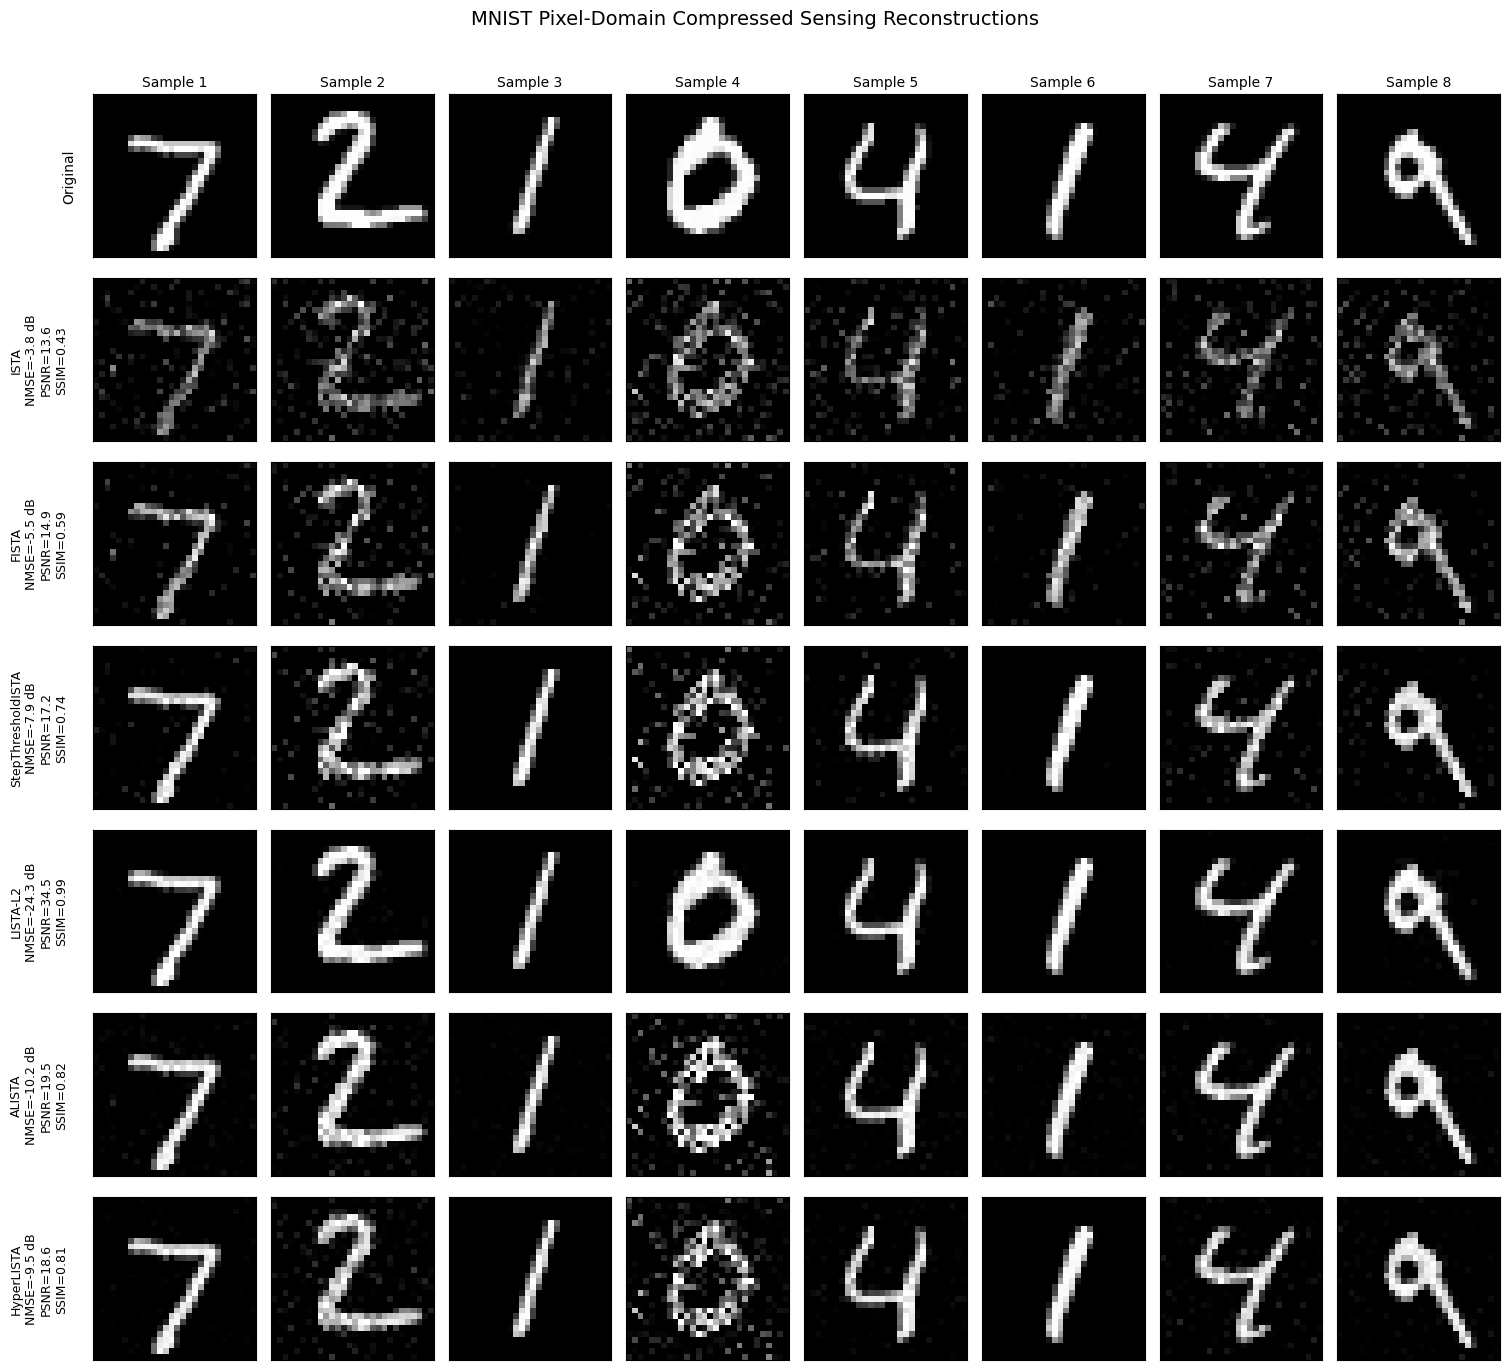

Saved figure to: ../results/notebook_04\mnist_ratio05_sigma00_K16_lamsweep_seed42\figures\mnist_reconstruction_grid.pdf


In [22]:
plot_models = [
    "ISTA",
    "FISTA",
    "StepThresholdISTA",
    "LISTA-L2",
    "ALISTA",
    "HyperLISTA",
]

n_rows = 1 + len(plot_models)
n_cols = N_SHOW

fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.9 * n_cols, 2.0 * n_rows))

# Make sure axes is always 2D
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
if n_cols == 1:
    axes = np.expand_dims(axes, axis=1)

# Column titles
for j in range(n_cols):
    axes[0, j].set_title(f"Sample {j+1}", fontsize=10)

# First row: original images
for j in range(n_cols):
    ax = axes[0, j]
    ax.imshow(x_vis[j].detach().cpu().reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    if j == 0:
        ax.set_ylabel("Original", fontsize=10, rotation=90, labelpad=12)

# Reconstruction rows
for i, name in enumerate(plot_models, start=1):
    if name not in reconstructions:
        continue

    x_hat = reconstructions[name]

    # Optional: add short metrics in row label
    nmse = results[name]["nmse_db"]
    psnr_val = results[name]["psnr"]
    ssim_val = results[name]["ssim"]
    row_label = f"{name}\nNMSE={nmse:.1f} dB\nPSNR={psnr_val:.1f}\nSSIM={ssim_val:.2f}"

    for j in range(n_cols):
        ax = axes[i, j]
        ax.imshow(x_hat[j].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(row_label, fontsize=9, rotation=90, labelpad=18)

fig.suptitle(
    f"{DATASET_NAME.upper()} Pixel-Domain Compressed Sensing Reconstructions",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])

fig_path = os.path.join(FIG_DIR, f"{DATASET_NAME}_reconstruction_grid.pdf")
plt.savefig(fig_path, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {fig_path}")